In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kmodes import KModes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [2]:
df=pd.read_csv("amazon_sales_2025_INR.xls")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=15000, step=1)
All columns are
0 Order_ID
1 Date
2 Customer_ID
3 Product_Category
4 Product_Name
5 Quantity
6 Unit_Price_INR
7 Total_Sales_INR
8 Payment_Method
9 Delivery_Status
10 Review_Rating
11 Review_Text
12 State
13 Country


In [3]:
def duplicates(column_name):
    counts = df[column_name].value_counts()
    duplicates = counts[counts > 1]
    result = duplicates.reset_index()
    result.columns = [column_name, 'Count']
    return result
a = duplicates("Product_Category")
b = duplicates("Product_Name")
c = duplicates("Payment_Method")
d = duplicates("Delivery_Status")
e = duplicates("Review_Rating")
f = duplicates("Review_Text")
g = duplicates("State")

print('Different product categories and their count\n')
print(a,'\n')

print('\nDifferent product name and their count\n')
print(b,'\n')
      
print('\nDifferent Payment Method and their count\n')
print(c,'\n')
      
print('\nDifferent Delivery status of every order and their count\n')
print(d,'\n')
      
print('\nDifferent Rating of all products and their achieved rating count\n')
print(e,'\n')
      
print('\nDifferent review text of orders and their count\n')
print(f,'\n')

print('\nDifferent state where item is and their count\n')
print(g,'\n')

Different product categories and their count

  Product_Category  Count
0      Electronics   3036
1            Books   3035
2         Clothing   3022
3           Beauty   2997
4   Home & Kitchen   2910 


Different product name and their count

        Product_Name  Count
0    Children's Book    636
1            Perfume    629
2   Science Textbook    624
3            T-Shirt    623
4             Laptop    618
5             Tablet    616
6         Smartwatch    615
7          Air Fryer    614
8         Headphones    610
9              Jeans    604
10            Jacket    601
11     Fiction Novel    599
12        Hair Dryer    599
13             Saree    598
14            Comics    597
15          Sneakers    596
16        Face Cream    596
17          Lipstick    590
18           Shampoo    583
19     Mixer Grinder    582
20         Biography    579
21        Smartphone    577
22      Cookware Set    577
23    Water Purifier    570
24    Vacuum Cleaner    567 


Different Payment Method

In [4]:
#dropping numerical and useless columns 
dfk = df[['Product_Category','Product_Name','Payment_Method','Delivery_Status','Review_Rating','State','Country']].copy()
print(dfk.index)
print("All columns are")
ai=0
for i in dfk:
    print(ai,i)
    ai+=1

#Review Rating as String
for col in dfk.columns:
    dfk[col] = dfk[col].astype(str)
print(dfk['Review_Rating'])

RangeIndex(start=0, stop=15000, step=1)
All columns are
0 Product_Category
1 Product_Name
2 Payment_Method
3 Delivery_Status
4 Review_Rating
5 State
6 Country
0        1
1        5
2        3
3        5
4        5
        ..
14995    1
14996    4
14997    1
14998    3
14999    4
Name: Review_Rating, Length: 15000, dtype: object


In [5]:
#Trying a random guess for clusters
km = KModes(n_clusters=8, init='Cao', verbose=1, random_state=42)

clusters = km.fit_predict(dfk)

dfk['Cluster_Labels'] = clusters

print(dfk[['Product_Name', 'Cluster_Labels']].head())

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 51191.0
   Product_Name  Cluster_Labels
0  Cookware Set               0
1    Hair Dryer               4
2        Tablet               2
3    Headphones               3
4         Saree               0


In [6]:
for i, centroid in enumerate(km.cluster_centroids_):
    print(f"\n--- Profile for Cluster {i} ---")
    for col, value in zip(dfk, centroid):
        print(f"{col}: {value}")


--- Profile for Cluster 0 ---
Product_Category: Clothing
Product_Name: T-Shirt
Payment_Method: Cash on Delivery
Delivery_Status: Delivered
Review_Rating: 5
State: Sikkim
Country: India

--- Profile for Cluster 1 ---
Product_Category: Books
Product_Name: Children's Book
Payment_Method: Credit Card
Delivery_Status: Pending
Review_Rating: 4
State: Rajasthan
Country: India

--- Profile for Cluster 2 ---
Product_Category: Electronics
Product_Name: Tablet
Payment_Method: Debit Card
Delivery_Status: Returned
Review_Rating: 3
State: Tamil Nadu
Country: India

--- Profile for Cluster 3 ---
Product_Category: Electronics
Product_Name: Smartwatch
Payment_Method: Credit Card
Delivery_Status: Delivered
Review_Rating: 2
State: Manipur
Country: India

--- Profile for Cluster 4 ---
Product_Category: Beauty
Product_Name: Perfume
Payment_Method: Debit Card
Delivery_Status: Pending
Review_Rating: 5
State: Assam
Country: India

--- Profile for Cluster 5 ---
Product_Category: Home & Kitchen
Product_Name: A

Clusters: 1 | Total Mismatch Cost: 85219.0
Clusters: 2 | Total Mismatch Cost: 73761.0
Clusters: 3 | Total Mismatch Cost: 66075.0
Clusters: 4 | Total Mismatch Cost: 62362.0
Clusters: 5 | Total Mismatch Cost: 58673.0
Clusters: 6 | Total Mismatch Cost: 55763.0
Clusters: 7 | Total Mismatch Cost: 53276.0
Clusters: 8 | Total Mismatch Cost: 51191.0
Clusters: 9 | Total Mismatch Cost: 50491.0
Clusters: 10 | Total Mismatch Cost: 49973.0
Clusters: 11 | Total Mismatch Cost: 49493.0
Clusters: 12 | Total Mismatch Cost: 49164.0
Clusters: 13 | Total Mismatch Cost: 48779.0
Clusters: 14 | Total Mismatch Cost: 48382.0
Clusters: 15 | Total Mismatch Cost: 48015.0
Clusters: 16 | Total Mismatch Cost: 47853.0
Clusters: 17 | Total Mismatch Cost: 47746.0
Clusters: 18 | Total Mismatch Cost: 47563.0
Clusters: 19 | Total Mismatch Cost: 47361.0


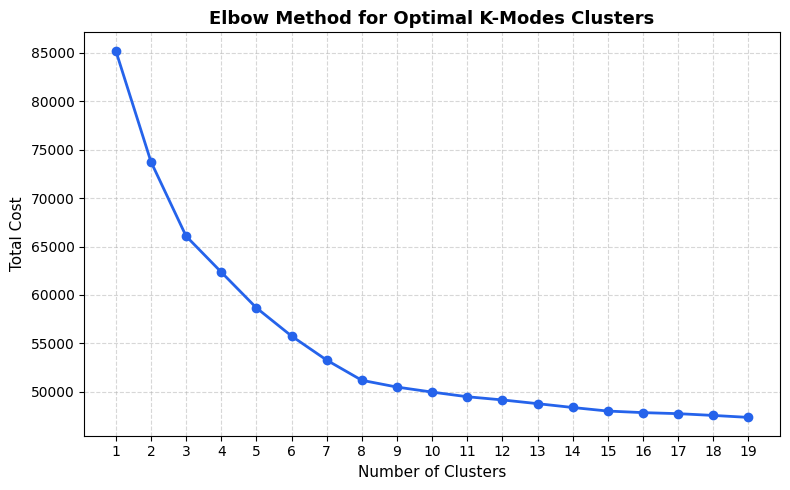

In [7]:
# For best numbers of clusters
k_range = range(1, 20)
cost_values = []

for k in k_range:
    km_test = KModes(n_clusters=k, init='Cao', verbose=0, random_state=42)
    km_test.fit_predict(dfk)
    
    cost_values.append(km_test.cost_)
    print(f"Clusters: {k} | Total Mismatch Cost: {cost_values[-1]}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, cost_values, marker='o', color='#2563EB', linewidth=2, markersize=6)
plt.title('Elbow Method for Optimal K-Modes Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters', fontsize=11)
plt.ylabel('Total Cost', fontsize=11)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [8]:
#As we can see from the above plot 4 or 5 clusters are the best value , after that there is no significant improvement
kmbest = KModes(n_clusters=4, init='Cao', verbose=1, random_state=42)

clusters = kmbest.fit_predict(dfk)

dfk['Cluster_Labels'] = clusters

print(dfk[['Product_Name', 'Cluster_Labels']].head())

for i, centroid in enumerate(kmbest.cluster_centroids_):
    print(f"\n--- Profile for Cluster {i} ---")
    for col, value in zip(dfk, centroid):
        print(f"{col}: {value}")

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 62362.0
   Product_Name  Cluster_Labels
0  Cookware Set               0
1    Hair Dryer               2
2        Tablet               2
3    Headphones               3
4         Saree               0

--- Profile for Cluster 0 ---
Product_Category: Clothing
Product_Name: T-Shirt
Payment_Method: Cash on Delivery
Delivery_Status: Delivered
Review_Rating: 5
State: Sikkim
Country: India
Cluster_Labels: 0

--- Profile for Cluster 1 ---
Product_Category: Books
Product_Name: Children's Book
Payment_Method: Credit Card
Delivery_Status: Pending
Review_Rating: 4
State: Rajasthan
Country: India
Cluster_Labels: 1

--- Profile for Cluster 2 ---
Product_Category: Electronics
Product_Name: Tablet
Payment_Method: Debit Card
Delivery_Status: Returned
Review_Rating: 3
State: Tamil Nadu
Country: India
Cluster_L

In [9]:
print('''Now we can infer some meaningful insights from the data such as -
Cookware and hair dryer are in same clusters meaning the buyer may be a woman and they are getting overall good ratings
Tablet belonging to electronic group also have good rating of 4''')

Now we can infer some meaningful insights from the data such as -
Cookware and hair dryer are in same clusters meaning the buyer may be a woman and they are getting overall good ratings
Tablet belonging to electronic group also have good rating of 4
